In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
from google.colab import drive

df = pd.read_csv('/content/drive/MyDrive/Dataset.csv')
df.shape
df.info()
df.describe()
df.head()
df.duplicated()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

np.int64(0)

In [37]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [38]:
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']
print(cat_col)
print(num_col)

['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color', 'Season', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Payment Method', 'Frequency of Purchases']
['Customer ID', 'Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']


In [39]:
df = df.drop(columns=['Item Purchased','Color','Size'], axis=1)
df.describe(include='all')

,Customer ID,Age,Gender,Category,Purchase Amount (USD),Location,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900.000000,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,4,NaN,50,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Clothing,NaN,Montana,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,1737,NaN,96,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,59.764359,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,23.685392,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,20.000000,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,39.000000,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,60.000000,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,81.000000,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [40]:
df['Review Rating'] = df['Review Rating'].fillna(df['Review Rating'].mean().round(2))
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Category,0
Purchase Amount (USD),0
Location,0
Season,0
Review Rating,0
Subscription Status,0
Shipping Type,0


<Axes: xlabel='Purchase Amount (USD)'>

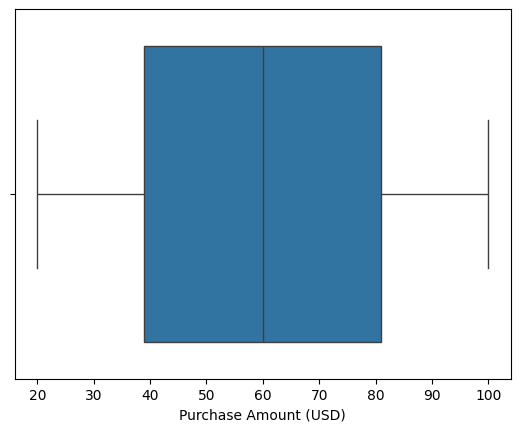

In [41]:
sns.boxplot(x=df['Purchase Amount (USD)'])


<Axes: xlabel='Previous Purchases'>

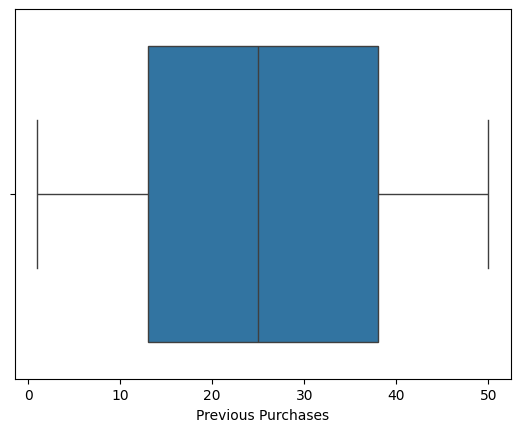

In [42]:
sns.boxplot(x=df['Previous Purchases'])

In [43]:
colx = ["Gender", "Category", "Location","Season", "Shipping Type", "Payment Method","Frequency of Purchases"]

for col in colx:
    unique_categories = pd.unique(df[col])

    print(f"{col}: {unique_categories}\n")

Gender: ['Male' 'Female']

Category: ['Clothing' 'Footwear' 'Outerwear' 'Accessories']

Location: ['Kentucky' 'Maine' 'Massachusetts' 'Rhode Island' 'Oregon' 'Wyoming'
 'Montana' 'Louisiana' 'West Virginia' 'Missouri' 'Arkansas' 'Hawaii'
 'Delaware' 'New Hampshire' 'New York' 'Alabama' 'Mississippi'
 'North Carolina' 'California' 'Oklahoma' 'Florida' 'Texas' 'Nevada'
 'Kansas' 'Colorado' 'North Dakota' 'Illinois' 'Indiana' 'Arizona'
 'Alaska' 'Tennessee' 'Ohio' 'New Jersey' 'Maryland' 'Vermont'
 'New Mexico' 'South Carolina' 'Idaho' 'Pennsylvania' 'Connecticut' 'Utah'
 'Virginia' 'Georgia' 'Nebraska' 'Iowa' 'South Dakota' 'Minnesota'
 'Washington' 'Wisconsin' 'Michigan']

Season: ['Winter' 'Spring' 'Summer' 'Fall']

Shipping Type: ['Express' 'Free Shipping' 'Next Day Air' 'Standard' '2-Day Shipping'
 'Store Pickup']

Payment Method: ['Venmo' 'Cash' 'Credit Card' 'PayPal' 'Bank Transfer' 'Debit Card']

Frequency of Purchases: ['Fortnightly' 'Weekly' 'Annually' 'Quarterly' 'Bi-Weekly' 'M

In [44]:
df['Subscription Status'] = df['Subscription Status'].map({
    'Yes': 1,
    'No': 0
})

freq = {
   'Fortnightly':3,
   'Weekly':2,
   'Annually':7,
   'Quarterly':6,
   'Bi-Weekly':1,
   'Monthly':4,
   'Every 3 Months':5
}

df['Frequency of Purchases'] = df['Frequency of Purchases'].map(freq)

df['Discount Applied'] = df['Discount Applied'].map({
    'Yes': 1,
    'No': 0
})

df['Promo Code Used'] = df['Promo Code Used'].map({
    'Yes': 1,
    'No': 0
})

In [45]:
df.head(20)

,Customer ID,Age,Gender,Category,Purchase Amount (USD),Location,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Clothing,53,Kentucky,Winter,3.1,1,Express,1,1,14,Venmo,3
1,2,19,Male,Clothing,64,Maine,Winter,3.1,1,Express,1,1,2,Cash,3
2,3,50,Male,Clothing,73,Massachusetts,Spring,3.1,1,Free Shipping,1,1,23,Credit Card,2
3,4,21,Male,Footwear,90,Rhode Island,Spring,3.5,1,Next Day Air,1,1,49,PayPal,2
4,5,45,Male,Clothing,49,Oregon,Spring,2.7,1,Free Shipping,1,1,31,PayPal,7
5,6,46,Male,Footwear,20,Wyoming,Summer,2.9,1,Standard,1,1,14,Venmo,2
6,7,63,Male,Clothing,85,Montana,Fall,3.2,1,Free Shipping,1,1,49,Cash,6
7,8,27,Male,Clothing,34,Louisiana,Winter,3.2,1,Free Shipping,1,1,19,Credit Card,2
8,9,26,Male,Outerwear,97,West Virginia,Summer,2.6,1,Express,1,1,8,Venmo,7
9,10,57,Male,Accessories,31,Missouri,Spring,4.8,1,2-Day Shipping,1,1,4,Cash,6


##CUSTOMER METRICS

#### 1. Promo Dependency



In [46]:
df['Promo Dependency'] = (df['Discount Applied'] + df['Promo Code Used'])
df['Promo Dependency'] = df['Promo Dependency'].fillna(0)

df.sample(5)


,Customer ID,Age,Gender,Category,Purchase Amount (USD),Location,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Promo Dependency
2506,2507,57,Male,Clothing,82,New York,Spring,4.4,0,Free Shipping,0,0,19,Venmo,7,0
1252,1253,28,Male,Footwear,41,Massachusetts,Fall,4.0,0,Standard,1,1,8,Cash,6,2
760,761,33,Male,Accessories,50,Minnesota,Fall,3.4,1,Free Shipping,1,1,6,Cash,7,2
2684,2685,46,Female,Clothing,45,Washington,Summer,4.7,0,Free Shipping,0,0,42,Credit Card,1,0
1019,1020,32,Male,Clothing,76,Kentucky,Winter,2.8,1,Standard,1,1,33,Venmo,1,2


####2. Customer Lifetime Value (Proxy)

In [47]:
df['CLV Proxy'] = df['Purchase Amount (USD)'] * df['Frequency of Purchases'] * df['Previous Purchases']
df['CLV Proxy'] = df['CLV Proxy'].fillna(0)

df.sample(5)


,Customer ID,Age,Gender,Category,Purchase Amount (USD),Location,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Promo Dependency,CLV Proxy
1294,1295,27,Male,Clothing,64,Texas,Summer,4.5,0,Standard,1,1,21,Cash,5,2,6720
2174,2175,42,Male,Accessories,49,Colorado,Spring,2.9,0,Store Pickup,0,0,1,Cash,7,0,343
3686,3687,59,Female,Footwear,70,Louisiana,Spring,4.8,0,Free Shipping,0,0,17,Cash,1,0,1190
3645,3646,38,Female,Accessories,90,Colorado,Summer,3.4,0,Free Shipping,0,0,31,Credit Card,5,0,13950
431,432,43,Male,Accessories,76,New Hampshire,Winter,3.4,1,Store Pickup,1,1,33,Cash,3,2,7524


####3. Loyal Customer Score A



In [48]:
df[['Previous Purchases',
    'Frequency of Purchases',
    'Subscription Status',
    'Purchase Amount (USD)',
    'Review Rating']].corr(numeric_only=True)

,Previous Purchases,Frequency of Purchases,Subscription Status,Purchase Amount (USD),Review Rating
Previous Purchases,1.000000,0.005530,0.030859,0.008063,0.003568
Frequency of Purchases,0.005530,1.000000,-0.005068,0.004585,0.009100
Subscription Status,0.030859,-0.005068,1.000000,-0.006996,-0.002200
Purchase Amount (USD),0.008063,0.004585,-0.006996,1.000000,0.029720
Review Rating,0.003568,0.009100,-0.002200,0.029720,1.000000


In [49]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,10))

df[['Previous Purchases Scaled','Frequency Scaled','Promo Dep Scaled','Subscription Scaled']] = scaler.fit_transform(df[['Previous Purchases','Frequency of Purchases','Promo Dependency','Subscription Status']]).round(2)
df.sample(5)

,Customer ID,Age,Gender,Category,Purchase Amount (USD),Location,Season,Review Rating,Subscription Status,Shipping Type,...,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Promo Dependency,CLV Proxy,Previous Purchases Scaled,Frequency Scaled,Promo Dep Scaled,Subscription Scaled
3694,3695,45,Female,Clothing,41,Rhode Island,Winter,2.6,0,Express,...,0,11,PayPal,1,0,451,2.04,0.00,0.0,0.0
1251,1252,56,Male,Clothing,86,Indiana,Spring,5.0,0,Next Day Air,...,1,43,Credit Card,4,2,14792,8.57,5.00,10.0,0.0
2363,2364,60,Male,Clothing,79,Pennsylvania,Winter,4.2,0,Express,...,0,38,Cash,1,0,3002,7.55,0.00,0.0,0.0
1322,1323,23,Male,Clothing,74,Washington,Winter,4.0,0,Next Day Air,...,1,17,Bank Transfer,6,2,7548,3.27,8.33,10.0,0.0
1763,1764,37,Male,Accessories,93,Vermont,Winter,3.9,0,Store Pickup,...,0,28,PayPal,7,0,18228,5.51,10.00,0.0,0.0


In [50]:
df['Loyalty Score A'] =  ((df['Previous Purchases Scaled'] + df['Frequency Scaled'] + 10 - df['Promo Dep Scaled']) / 3).round(2)
df.sample(5)

,Customer ID,Age,Gender,Category,Purchase Amount (USD),Location,Season,Review Rating,Subscription Status,Shipping Type,...,Previous Purchases,Payment Method,Frequency of Purchases,Promo Dependency,CLV Proxy,Previous Purchases Scaled,Frequency Scaled,Promo Dep Scaled,Subscription Scaled,Loyalty Score A
133,134,52,Male,Clothing,65,Montana,Winter,2.5,1,Next Day Air,...,25,Venmo,7,2,11375,4.90,10.00,10.0,10.0,4.97
1155,1156,67,Male,Clothing,53,Tennessee,Fall,2.6,0,Express,...,47,PayPal,6,2,14946,9.39,8.33,10.0,0.0,5.91
1969,1970,64,Male,Clothing,32,Louisiana,Winter,3.5,0,Next Day Air,...,11,Bank Transfer,3,0,1056,2.04,3.33,0.0,0.0,5.12
757,758,41,Male,Clothing,32,Minnesota,Fall,3.8,1,Store Pickup,...,18,Debit Card,6,2,3456,3.47,8.33,10.0,10.0,3.93
3063,3064,26,Female,Accessories,43,Connecticut,Winter,3.9,0,Store Pickup,...,24,Credit Card,3,0,3096,4.69,3.33,0.0,0.0,6.01


In [51]:
df['Loyalty Score A'].describe()

,Loyalty Score A
count,3900.000000
mean,5.246746
std,2.205781
min,0.000000
25%,3.610000
50%,5.290000
75%,6.900000
max,10.000000


####4. Loyal Customer Score B

In [52]:
df['Loyalty Score B'] =  ((df['Previous Purchases Scaled'] + df['Frequency Scaled'] + df['Subscription Scaled']) / 3).round(2)
df.sample(5)

,Customer ID,Age,Gender,Category,Purchase Amount (USD),Location,Season,Review Rating,Subscription Status,Shipping Type,...,Payment Method,Frequency of Purchases,Promo Dependency,CLV Proxy,Previous Purchases Scaled,Frequency Scaled,Promo Dep Scaled,Subscription Scaled,Loyalty Score A,Loyalty Score B
2017,2018,70,Male,Clothing,32,Massachusetts,Winter,4.1,0,Next Day Air,...,Bank Transfer,5,0,6720,8.37,6.67,0.0,0.0,8.35,5.01
2790,2791,34,Female,Clothing,63,Maine,Spring,4.5,0,Free Shipping,...,Debit Card,7,0,10584,4.69,10.00,0.0,0.0,8.23,4.90
1226,1227,53,Male,Footwear,91,Ohio,Fall,3.4,0,Store Pickup,...,Venmo,1,2,1638,3.47,0.00,10.0,0.0,1.16,1.16
76,77,50,Male,Accessories,43,Delaware,Summer,4.2,1,Free Shipping,...,Venmo,4,2,5504,6.33,5.00,10.0,10.0,3.78,7.11
2691,2692,43,Female,Clothing,25,Nebraska,Winter,3.3,0,2-Day Shipping,...,Cash,4,0,4800,9.59,5.00,0.0,0.0,8.20,4.86


## Choosing best of score A or B

In [53]:
print(df[['Loyalty Score A','Loyalty Score B']].corr())

                 Loyalty Score A  Loyalty Score B
Loyalty Score A         1.000000         0.107913
Loyalty Score B         0.107913         1.000000


In [54]:
df[['Loyalty Score A','Loyalty Score B']].sample(10)

,Loyalty Score A,Loyalty Score B
3480,7.99,4.66
2182,5.03,1.70
1104,3.25,3.25
3673,6.48,3.15
2469,8.44,5.10
765,3.59,6.93
2511,6.11,2.78
2936,6.95,3.62
2663,8.16,4.83
3808,3.67,0.34


In [55]:
print(df['Loyalty Score A'].describe())
print(df['Loyalty Score B'].describe())

count    3900.000000
mean        5.246746
std         2.205781
min         0.000000
25%         3.610000
50%         5.290000
75%         6.900000
max        10.000000
Name: Loyalty Score A, dtype: float64
count    3900.000000
mean        4.246805
std         2.115668
min         0.000000
25%         2.700000
50%         4.070000
75%         5.652500
max        10.000000
Name: Loyalty Score B, dtype: float64


In [56]:
df.rename(columns={'Loyalty Score A': 'Loyalty Score'}, inplace=True)
df.drop(columns=['Loyalty Score B'], inplace=True)
df.head(5)

,Customer ID,Age,Gender,Category,Purchase Amount (USD),Location,Season,Review Rating,Subscription Status,Shipping Type,...,Previous Purchases,Payment Method,Frequency of Purchases,Promo Dependency,CLV Proxy,Previous Purchases Scaled,Frequency Scaled,Promo Dep Scaled,Subscription Scaled,Loyalty Score
0,1,55,Male,Clothing,53,Kentucky,Winter,3.1,1,Express,...,14,Venmo,3,2,2226,2.65,3.33,10.0,10.0,1.99
1,2,19,Male,Clothing,64,Maine,Winter,3.1,1,Express,...,2,Cash,3,2,384,0.20,3.33,10.0,10.0,1.18
2,3,50,Male,Clothing,73,Massachusetts,Spring,3.1,1,Free Shipping,...,23,Credit Card,2,2,3358,4.49,1.67,10.0,10.0,2.05
3,4,21,Male,Footwear,90,Rhode Island,Spring,3.5,1,Next Day Air,...,49,PayPal,2,2,8820,9.80,1.67,10.0,10.0,3.82
4,5,45,Male,Clothing,49,Oregon,Spring,2.7,1,Free Shipping,...,31,PayPal,7,2,10633,6.12,10.00,10.0,10.0,5.37


###5. Satisfaction Flag and CSAT (Proxy)


In [57]:
df['Review Rating'].describe()

,Review Rating
count,3900.000000
mean,3.750064
std,0.713573
min,2.500000
25%,3.100000
50%,3.750000
75%,4.400000
max,5.000000


In [58]:
df['Satisfaction Tier'] = (df['Review Rating'] > df['Review Rating'].mean()).astype(int)

csat_proxy = df['Satisfaction Tier'].mean()*100
# csat_proxy = ((df['Satisfaction Tier']==1).sum()/ df['Customer ID'].count())*100
print(csat_proxy)

df[['Review Rating', 'Satisfaction Tier']].sample(5)

49.666666666666664


,Review Rating,Satisfaction Tier
3746,2.6,0
2794,3.3,0
502,2.8,0
1930,3.5,0
3676,4.9,1


##Customer Segmentation

In [59]:
clv_cutoff = df['CLV Proxy'].median()
loyalty_cutoff = 7

conditions = [
    (df['CLV Proxy'] >= clv_cutoff) & (df['Loyalty Score'] >= loyalty_cutoff),
    (df['CLV Proxy'] >= clv_cutoff) & (df['Loyalty Score'] < loyalty_cutoff),
    (df['CLV Proxy'] < clv_cutoff) & (df['Loyalty Score'] >= loyalty_cutoff),
    (df['CLV Proxy'] < clv_cutoff) & (df['Loyalty Score'] < loyalty_cutoff)
]

choices = [
    'Platinum Champions',
    'At-Risk High-Value',
    'Emerging Devotees',
    'Low-Engagement Casuals'
]

df['Customer Segment'] = np.select(conditions, choices, default = 'Others')

In [60]:
df['Customer Segment'].value_counts()

,count
Customer Segment,
Low-Engagement Casuals,1855
At-Risk High-Value,1118
Platinum Champions,834
Emerging Devotees,93


### Segment Profiling

##### Demographic profile → Age, Gender
##### Behavioral profile → Purchase Amount, Previous Purchases, Promo Dependency
##### Product preference → Category
##### Payment preference → Payment Method
##### Geographic profile → Location

In [61]:
def most_common(x):
    return x.mode()[0]

df.groupby('Customer Segment').agg({
    'Purchase Amount (USD)': 'mean',
    'Previous Purchases': 'mean',
    'Age': 'mean',
    'Review Rating': 'mean',
    'Promo Dependency': 'mean',
    'Gender': most_common,
    'Category': most_common,
    'Payment Method': most_common,
    'Location': most_common
}).round(2)

,Purchase Amount (USD),Previous Purchases,Age,Review Rating,Promo Dependency,Gender,Category,Payment Method,Location
Customer Segment,,,,,,,,,
At-Risk High-Value,69.40,31.66,44.03,3.75,1.51,Male,Clothing,Credit Card,Pennsylvania
Emerging Devotees,34.42,21.59,47.06,3.73,0.00,Male,Clothing,Venmo,Connecticut
Low-Engagement Casuals,53.50,17.19,43.53,3.74,0.90,Male,Clothing,PayPal,Illinois
Platinum Champions,63.61,35.48,45.00,3.78,0.00,Female,Clothing,Credit Card,Idaho


In [62]:
df.sample(5)

,Customer ID,Age,Gender,Category,Purchase Amount (USD),Location,Season,Review Rating,Subscription Status,Shipping Type,...,Frequency of Purchases,Promo Dependency,CLV Proxy,Previous Purchases Scaled,Frequency Scaled,Promo Dep Scaled,Subscription Scaled,Loyalty Score,Satisfaction Tier,Customer Segment
3177,3178,55,Female,Accessories,52,Missouri,Fall,3.2,0,Standard,...,4,0,6448,6.12,5.00,0.0,0.0,7.04,0,Platinum Champions
1217,1218,50,Male,Footwear,63,Nebraska,Fall,2.6,0,Free Shipping,...,5,2,3780,2.24,6.67,10.0,0.0,2.97,0,Low-Engagement Casuals
955,956,55,Male,Clothing,75,Mississippi,Summer,3.4,1,Free Shipping,...,4,2,1200,0.61,5.00,10.0,10.0,1.87,0,Low-Engagement Casuals
1996,1997,67,Male,Footwear,27,South Dakota,Summer,3.3,0,Next Day Air,...,5,0,2430,3.47,6.67,0.0,0.0,6.71,0,Low-Engagement Casuals
1027,1028,33,Male,Accessories,90,Ohio,Summer,2.8,1,Next Day Air,...,4,2,3960,2.04,5.00,10.0,10.0,2.35,0,Low-Engagement Casuals


In [63]:
pd.crosstab(df['Customer Segment'], df['Category'], normalize='index').round(3) * 100

Category,Accessories,Clothing,Footwear,Outerwear
Customer Segment,,,,
At-Risk High-Value,32.2,43.1,17.0,7.7
Emerging Devotees,28.0,46.2,18.3,7.5
Low-Engagement Casuals,31.0,45.5,14.7,8.8
Platinum Champions,33.5,44.1,14.4,8.0


In [64]:
# df.to_excel("datasetfinal.xlsx", index=False)
# from google.colab import files
# files.download("datasetfinal.xlsx")

In [65]:
# df.to_csv("dataset1.csv", index=False)
# from google.colab import files
# files.download("dataset1.csv")